In [4]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

```
Дан пайплайн для тренировки сегментации с датасетом Oxford-IIIT Pet. Задача - доделать тренировку и провести эксперименты 

Критерии
3 - просто доделан класс U-Net и обучен. Можно сделать его чисто на своих свертках / либо взять готовый бекбон из torchvision.models по типу ResNet34 и достать из него признаки для skip connections
4 - обучен U-Net и проведен перебор простых гиперпараметров в конфиге (lr, batch size и тд) с графиками после тренировки. Перебор хватит делать по 3 значениям для 2 параметров. После полезно написать мысли, почему получились такие результаты
5 - обучен U-Net , проведен перебор гиперпаметров выше и проверена какая-либо идея по модификации U-Net (сделать глубже, добавить нормализацию слоев, поменять бекбон на другой, и тд). Также сделать 1-2 графика с результатами. После написать мысли, почему получились такие результаты

Дедлайн - 2 недели (то есть 21.03)

В пайплайне есть конфиг, с ним можно удобно менять параметры, если нужно туда можно добавить еще что-то, чтобы не перезапускать код много раз. Перебор гиперпараметров можно сделать в цикле над всем обучением или в тулзах типо WandB если уже юзали их. Если что-то хочется переделать в пайплайне под свое удобство - полная свобода здесь
```

In [5]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 0.0001
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_split: float = 0.8   

config = Config()

In [6]:
# class UNet(nn.Module):
#     def __init__(self, in_channels=3, out_channels=1):
#         super(UNet, self).__init__()

#         # тут слои обозначить для encoder, bottleneck и decoder

#     def forward(self, x):
#         # тут предсказать маску

#         return

In [7]:
# Взял код из домашки DLS по сегментации
class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.seq(x)

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, last=False):
        super().__init__()
        if last:
            self.seq = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.seq = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(in_channels),
                nn.ReLU(),
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU()
            )

    def forward(self, x1, x2):
        #print('------       x1, x2, x')
        #print(x1.shape)
        #print(x2.shape)
        #x = torch.cat((x1, x2), dim=1)
        x = x1 + x2
        #print(x.shape)
        return self.seq(x)

class UNet(nn.Module):
    name = "UNet v1"
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        # Each enc_conv/dec_conv block should look like this:
        # nn.Sequential(
        #     nn.Conv2d(...),
        #     ... (2 or 3 conv layers with relu and batchnorm),
        # )
        self.enc_conv0 = Encoder(3, 64)
        self.pool0 = nn.MaxPool2d(2, stride=2, return_indices =True)  # 256 -> 128
        self.enc_conv1 = Encoder(64, 128)
        self.pool1 = nn.MaxPool2d(2, stride=2, return_indices =True) # 128 -> 64
        self.enc_conv2 = Encoder(128, 256)
        self.pool2 = nn.MaxPool2d(2, stride=2, return_indices =True) # 64 -> 32
        self.enc_conv3 =Encoder(256, 512)
        self.pool3 = nn.MaxPool2d(2, stride=2, return_indices =True) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(
                nn.Conv2d(512, 1024, kernel_size=3, padding=1),
                nn.BatchNorm2d(1024),
                nn.ReLU(),
                nn.Conv2d(1024, 512, kernel_size=3, padding=1),
                nn.BatchNorm2d(512),
                nn.ReLU()
            )

        # decoder (upsampling)
        self.upsample0 = nn.MaxUnpool2d(2, stride=2) # 16 -> 32
        self.dec_conv0 = Decoder(512, 256)
        self.upsample1 = nn.MaxUnpool2d(2, stride=2) # 32 -> 64
        self.dec_conv1 = Decoder(256, 128)
        self.upsample2 = nn.MaxUnpool2d(2, stride=2)  # 64 -> 128
        self.dec_conv2 = Decoder(128, 64)
        self.upsample3 = nn.MaxUnpool2d(2, stride=2)  # 128 -> 256
        self.dec_conv3 = Decoder(64, 1, last=True)

    def forward(self, x):
        # encoder
        e0 = self.enc_conv0(x)
        e01, i0 = self.pool0(e0)
        e1 = self.enc_conv1(e01)
        e11, i1 = self.pool1(e1)
        e2 = self.enc_conv2(e11)
        e21, i2 = self.pool2(e2)
        e3 = self.enc_conv3(e21)
        e31, i3 = self.pool3(e3)

        # bottleneck
        b = self.bottleneck_conv(e31)

        # decoder
        
        d0 = self.dec_conv0(self.upsample0(b, i3), e3)
        #print(d0.shape, i2.shape)
        d1 = self.dec_conv1(self.upsample1(d0, i2), e2)
        d2 = self.dec_conv2(self.upsample2(d1, i1), e1)
        d3 = self.dec_conv3(self.upsample3(d2, i0), e0)    # no activation
        return d3

In [8]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [9]:
!pip install segmentation_models_pytorch


In [10]:
from segmentation_models_pytorch.losses import DiceLoss

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [11]:
def dice_loss(y_pred, y_real):
    y_pred = torch.sigmoid(y_pred)
    smooth = 1e-8
    num = (2. * torch.sum((y_real * y_pred))) + smooth
    den = (y_pred.sum() + y_real.sum() + smooth)
    res = 1 - (num / den).mean()
    return res  

In [101]:
class Trainer:
    def __init__(self, config, model):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = model.to(config.device)
        self.criterion = dice_loss
        #DiceLoss(mode='binary', from_logits=True) # какой лосс удобный возьмем для бинарной сегментации?
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

        self.losses = {'train': [], 'val': [], 'test': []}
        self.accuracies = {'train': [], 'val': [], 'test': []}

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.losses['train'].append(train_loss)
            self.losses['val'].append(val_loss)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        self.losses['test'].append(test_loss)
        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            #print('device right before forward', next(self.model.parameters()).device.type)
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

            

            

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()


In [13]:
#trainer = Trainer(config)

In [14]:
#trainer.run()

In [15]:
#trainer.inference_and_plot_samples(n_samples=10)

In [16]:
from sklearn.model_selection import ParameterGrid
from dataclasses import replace

param_grid = {
    'batch_size': [32, 64, 128],
    'learning_rate': [0.0001, 0.0005, 0.001],
#    'epochs': [0],
#    'train_split': [0.8]
}

train_results = []

base_config = Config()

total_combinations = len(list(ParameterGrid(param_grid)))

trainers = []

for params in ParameterGrid(param_grid):
    config_new = replace(base_config, **params)
    trainer = Trainer(config_new, UNet()) # честно говоря я сначала думал что это плохая идея создавать новый трейнер каждый раз, потому что он съест ресурсы. Но вроде работает нормально и я оставил
    trainer.run()
    trainers.append([config_new, trainer])


/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


Epoch 1 / 15, Train Loss: 0.3204, Val Loss: 0.3035, Val IoU: 0.7551, Val F1-score: 0.8541


100%|██████████| 23/23 [00:10<00:00,  2.15it/s]


Epoch 2 / 15, Train Loss: 0.2861, Val Loss: 0.2880, Val IoU: 0.7944, Val F1-score: 0.8797


100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


...

Epoch 14 / 15, Train Loss: 0.1984, Val Loss: 0.2048, Val IoU: 0.8651, Val F1-score: 0.9236


100%|██████████| 6/6 [00:10<00:00,  1.74s/it]


Epoch 15 / 15, Train Loss: 0.1949, Val Loss: 0.2148, Val IoU: 0.8364, Val F1-score: 0.9051
Testing...


100%|██████████| 29/29 [00:52<00:00,  1.82s/it]

Test Loss: 0.2148, Test IoU: 0.8349, Test F1-score: 0.9033


In [17]:
!nvidia-smi

Tue Mar 24 18:28:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             37W /  250W |   14805MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

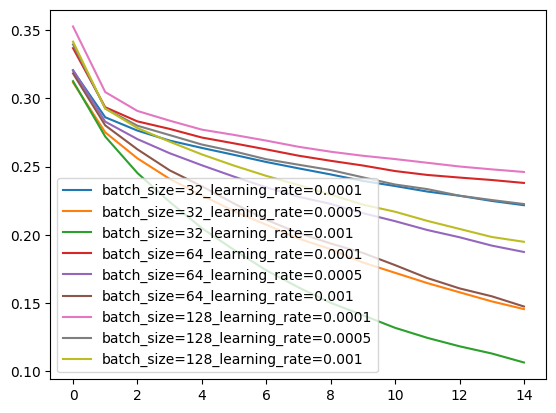

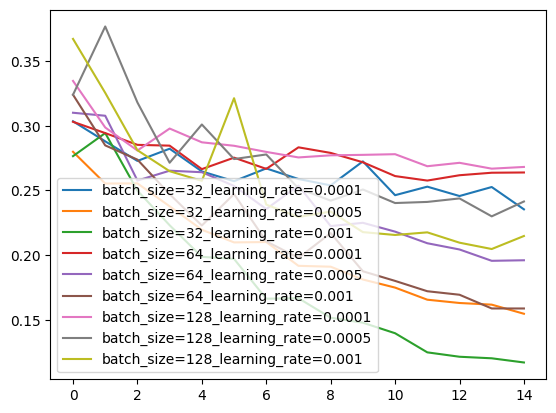

In [18]:

changed_params = param_grid.keys()
def expirement_name(config):
    text = []
    for key in changed_params:
        text.append(f"{key}={getattr(config, key)}")
    return "_".join(text)

for en, (config, trainer) in enumerate(trainers):
    plt.plot(trainer.losses['train'], label=expirement_name(config))
plt.legend()
plt.show()

for en, (config, trainer) in enumerate(trainers):
    plt.plot(trainer.losses['val'], label=expirement_name(config))
plt.legend()
plt.show()

ну с большим лернингрейтом модель обучилась быстрее (логично вцелом)

среди моделей с одинаковым лернингрейтом больший батчсайз дал результаты хуже. Тут я не очень понимаю почему

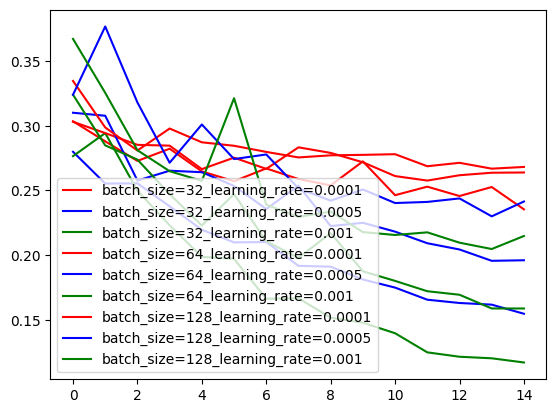

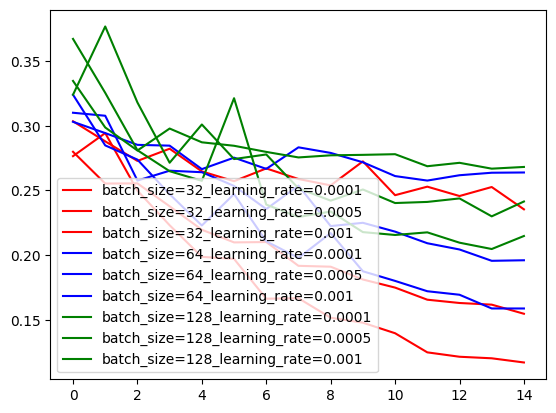

In [22]:
colors = ['red', 'blue', 'green']
for en, (config, trainer) in enumerate(trainers):
    plt.plot(trainer.losses['val'], label=expirement_name(config), color=colors[param_grid['learning_rate'].index(config.learning_rate)])
plt.legend()
plt.show()
colors = ['red', 'blue', 'green']
for en, (config, trainer) in enumerate(trainers):
    plt.plot(trainer.losses['val'], label=expirement_name(config), color=colors[param_grid['batch_size'].index(config.batch_size)])
plt.legend()
plt.show()

## Самая хорошая и самая плохая модель

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

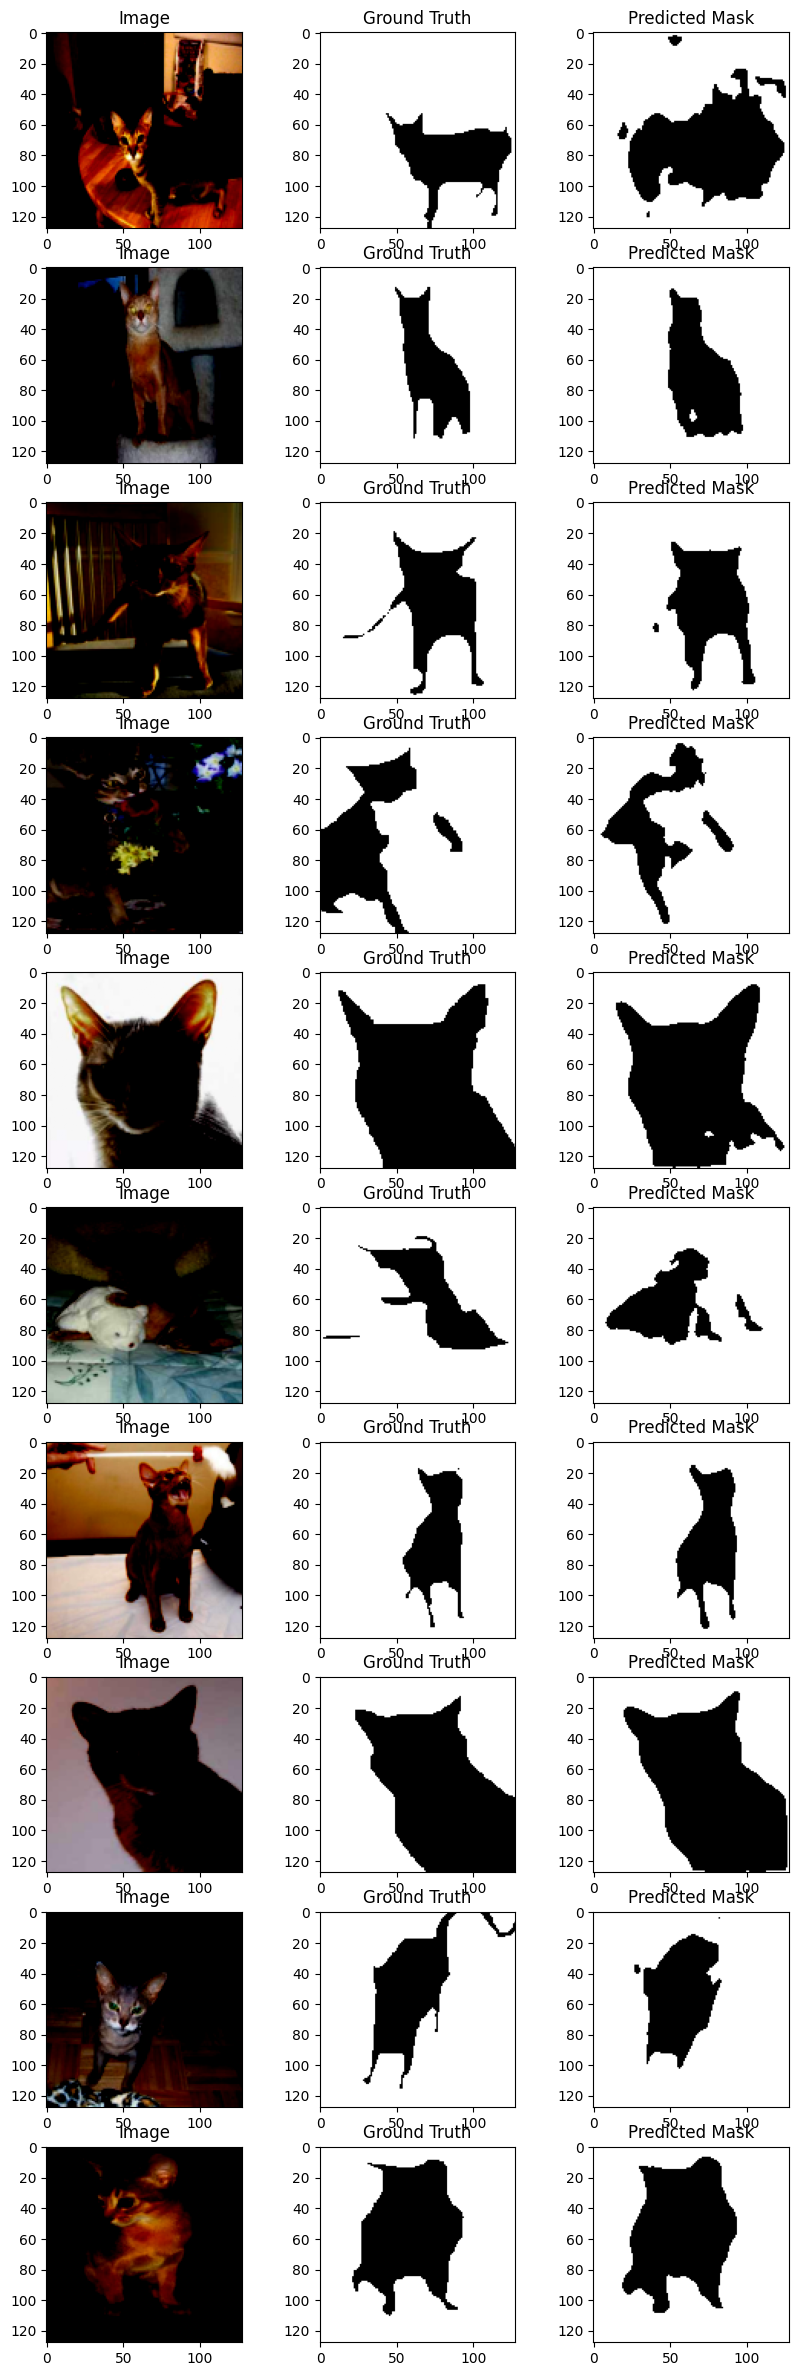

In [104]:
for en, (config, trainer) in enumerate(trainers):
    if config.batch_size == 32 and config.learning_rate == 0.001:
        trainer.inference_and_plot_samples(n_samples=10)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

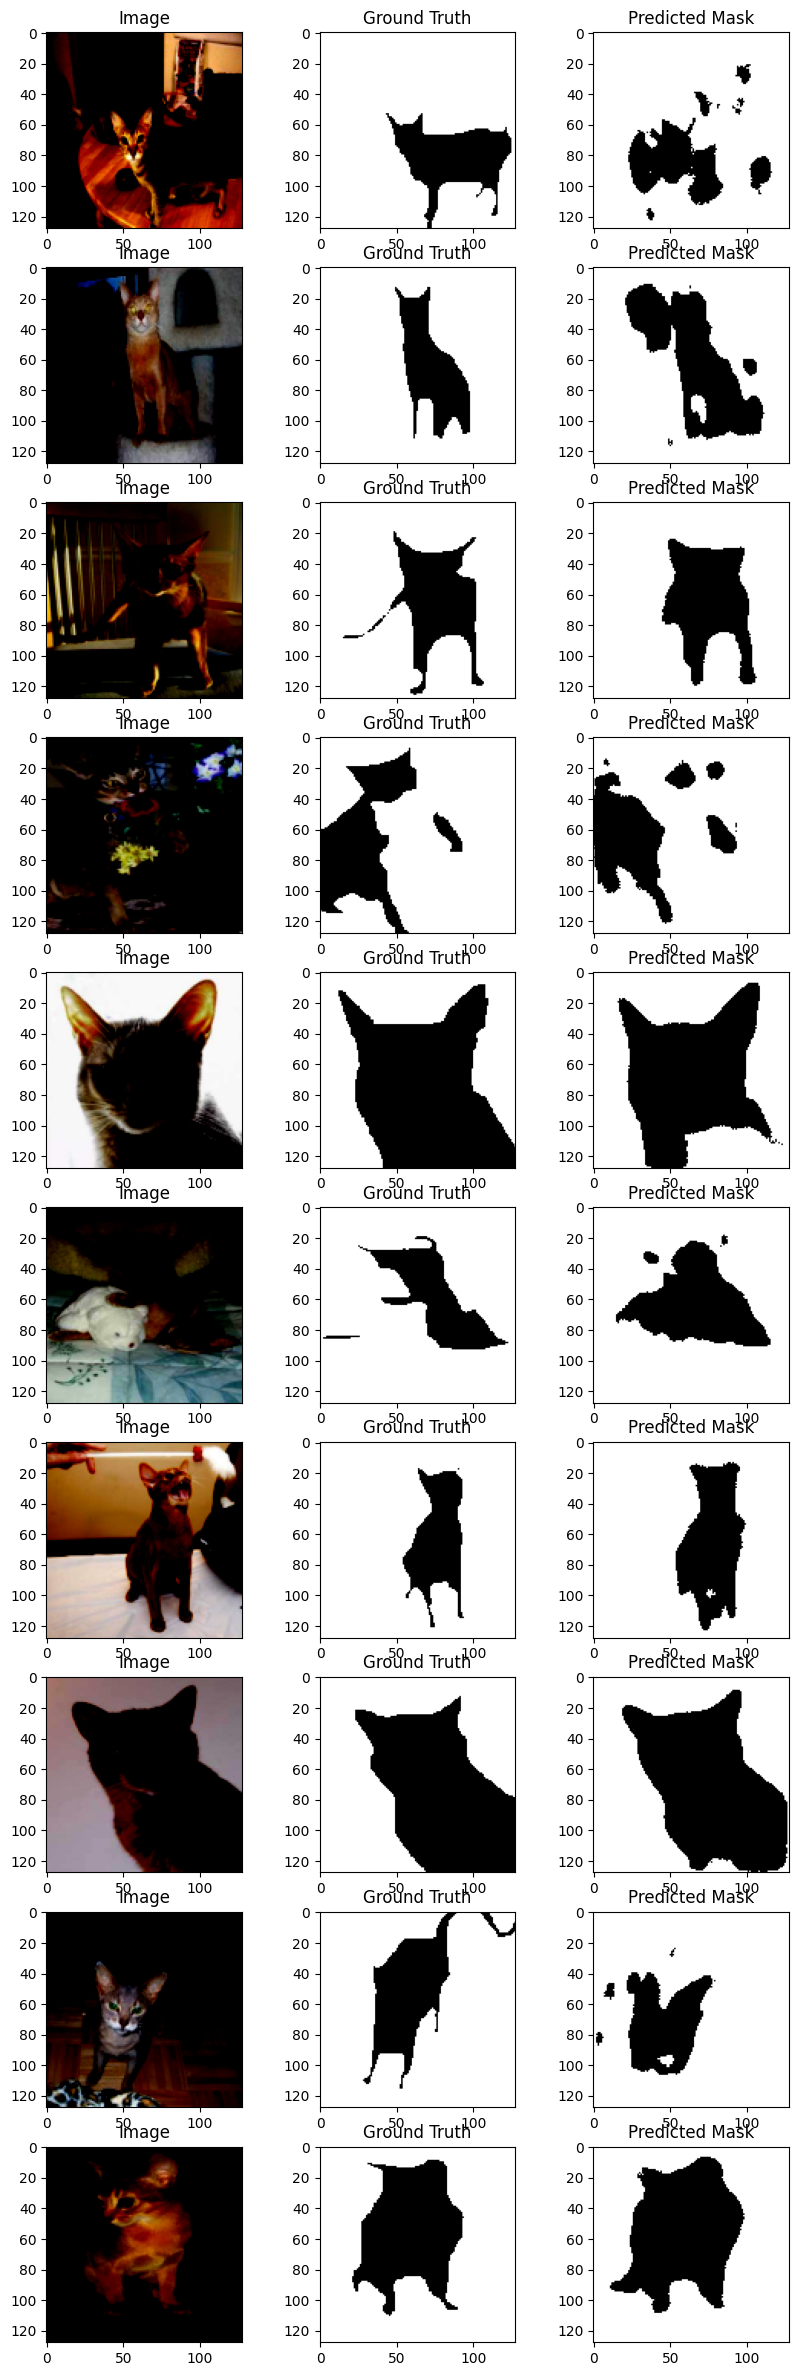

In [105]:
for en, (config, trainer) in enumerate(trainers):
    if config.batch_size == 128 and config.learning_rate == 0.0001:
        trainer.inference_and_plot_samples(n_samples=10)

# Давайте попробуем облегчить модель и посмотреть насколько она будет хуже.
сравним насколько уменьшится качество при уменьшении количества блоков

In [102]:
class UNet_custom(nn.Module):
    name = "UNet configurable"

    def __init__(self, blocks_count=4):
        super().__init__()

        # encoder (downsampling)
        # Each enc_conv/dec_conv block should look like this:
        # nn.Sequential(
        #     nn.Conv2d(...),
        #     ... (2 or 3 conv layers with relu and batchnorm),
        # )
        
        assert blocks_count > 0

        self.blocks_count = blocks_count

        self.encoders = []
        self.poolings = []
        self.bottleneck = []
        self.decoders = []
        self.unpoolings = []

        input_channels = 3
        output_channels = 64

        for i in range(blocks_count):
            self.encoders.append(Encoder(input_channels, output_channels))
            self.poolings.append(
                nn.MaxPool2d(2, stride=2, return_indices=True)
            )  # 256 -> 128
            input_channels = output_channels
            output_channels *= 2

        # bottleneck

        self.bottleneck = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(),
            nn.Conv2d(output_channels, input_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(input_channels),
            nn.ReLU(),
        )

        # decoder (upsampling)
        output_channels = input_channels // 2

        for _ in range(blocks_count - 1):
            print(f"decoder {i}: {input_channels} -> {output_channels}")
            self.unpoolings.append(nn.MaxUnpool2d(2, stride=2))
            self.decoders.append(Decoder(input_channels, output_channels))
            # print(input_channels, output_channels)
            input_channels = output_channels
            output_channels //= 2

        self.unpoolings.append(nn.MaxUnpool2d(2, stride=2))
        self.decoders.append(Decoder(input_channels, 1, last=True))

        self.modules_all = nn.ModuleList(self.encoders + self.poolings + self.unpoolings + self.decoders)

    def forward(self, x):

        enc_res = []
        i_res = []

        for i in range(self.blocks_count):
            enc_res.append(self.encoders[i](x))
            x, i = self.poolings[i](enc_res[-1])
            i_res.append(i)

        x = self.bottleneck(x)

        for i in range(self.blocks_count):
            x = self.unpoolings[i](x, i_res[-1-i])
            x = self.decoders[i](x, enc_res[-1-i])

        return x

In [111]:
best_config = Config(
    learning_rate=0.001,
    batch_size=32,
)

custom_results = []

for layers_count in range(1, 5):
    model = UNet_custom(blocks_count=layers_count)
    #model.to(config.device)
    
    trainer = Trainer(best_config, model)
    #print(next(model.parameters()).device.type)
    trainer.run()
    
    custom_results.append(trainer)




/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 23/23 [00:09<00:00,  2.32it/s]


Epoch 1 / 15, Train Loss: 0.3482, Val Loss: 0.3380, Val IoU: 0.6062, Val F1-score: 0.7374


100%|██████████| 23/23 [00:09<00:00,  2.33it/s]


Epoch 2 / 15, Train Loss: 0.2986, Val Loss: 0.2752, Val IoU: 0.7178, Val F1-score: 0.8254


100%|██████████| 23/23 [00:09<00:00,  2.32it/s]


...

Epoch 14 / 15, Train Loss: 0.1109, Val Loss: 0.1198, Val IoU: 0.8699, Val F1-score: 0.9265


100%|██████████| 23/23 [00:10<00:00,  2.22it/s]


Epoch 15 / 15, Train Loss: 0.1052, Val Loss: 0.1150, Val IoU: 0.8722, Val F1-score: 0.9278
Testing...


100%|██████████| 115/115 [00:52<00:00,  2.19it/s]

Test Loss: 0.1137, Test IoU: 0.8749, Test F1-score: 0.9287


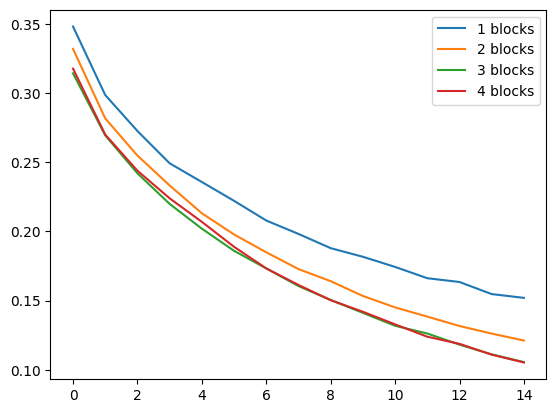

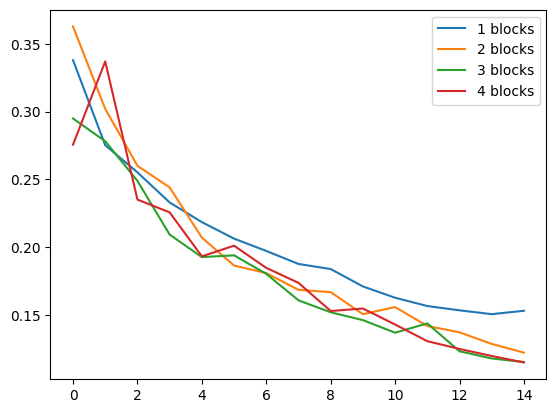

In [113]:

for en, trainer in enumerate(custom_results):
    plt.plot(trainer.losses['train'], label=f'{en + 1} blocks')
plt.legend()
plt.show()

for en, trainer in enumerate(custom_results):
    plt.plot(trainer.losses['val'], label=f'{en + 1} blocks')
plt.legend()
plt.show()

3 и 4 блока в глубину уже почти не дают прироста (если честно то это странно)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1


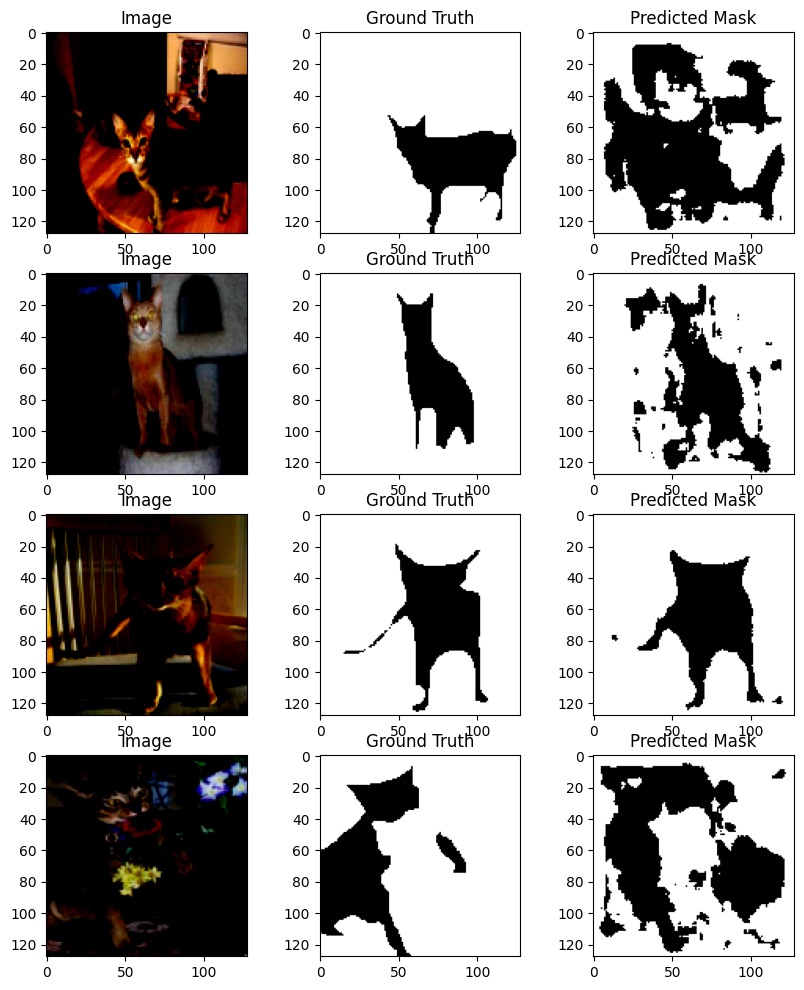

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


2


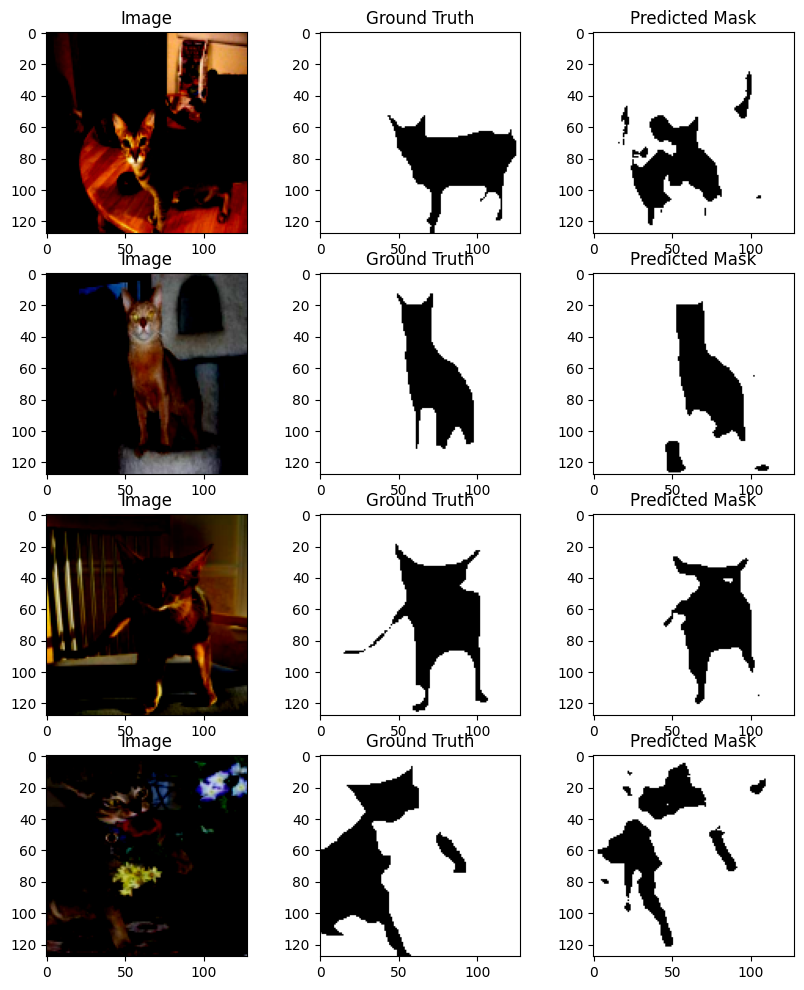

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


3


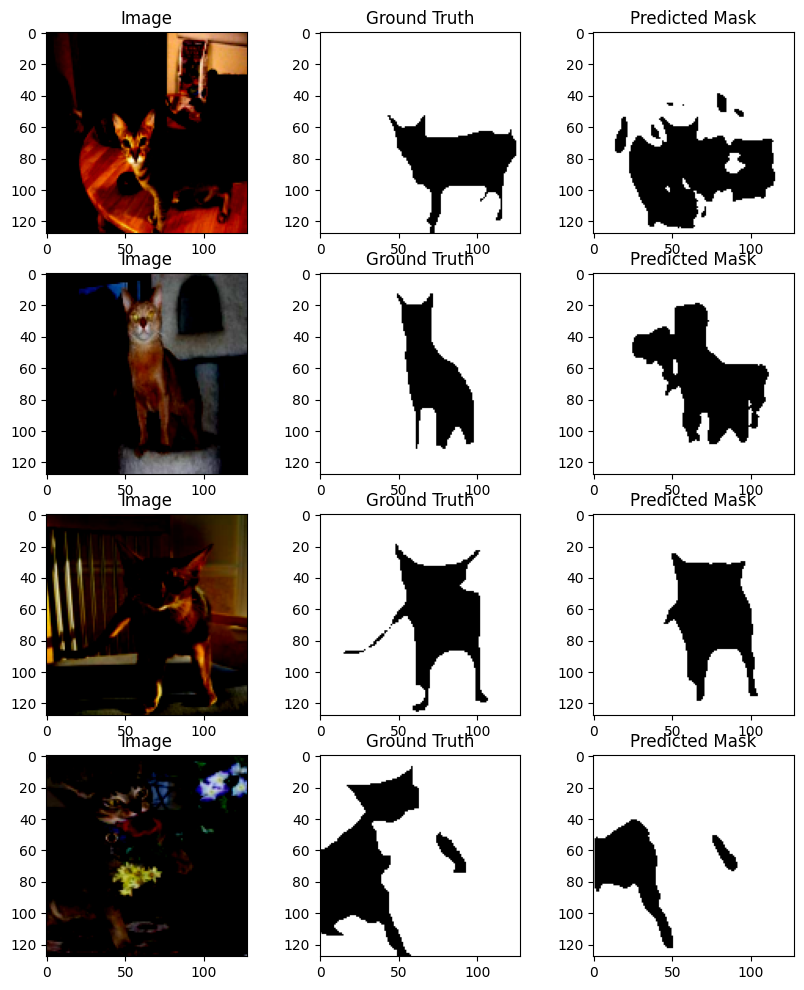

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


4


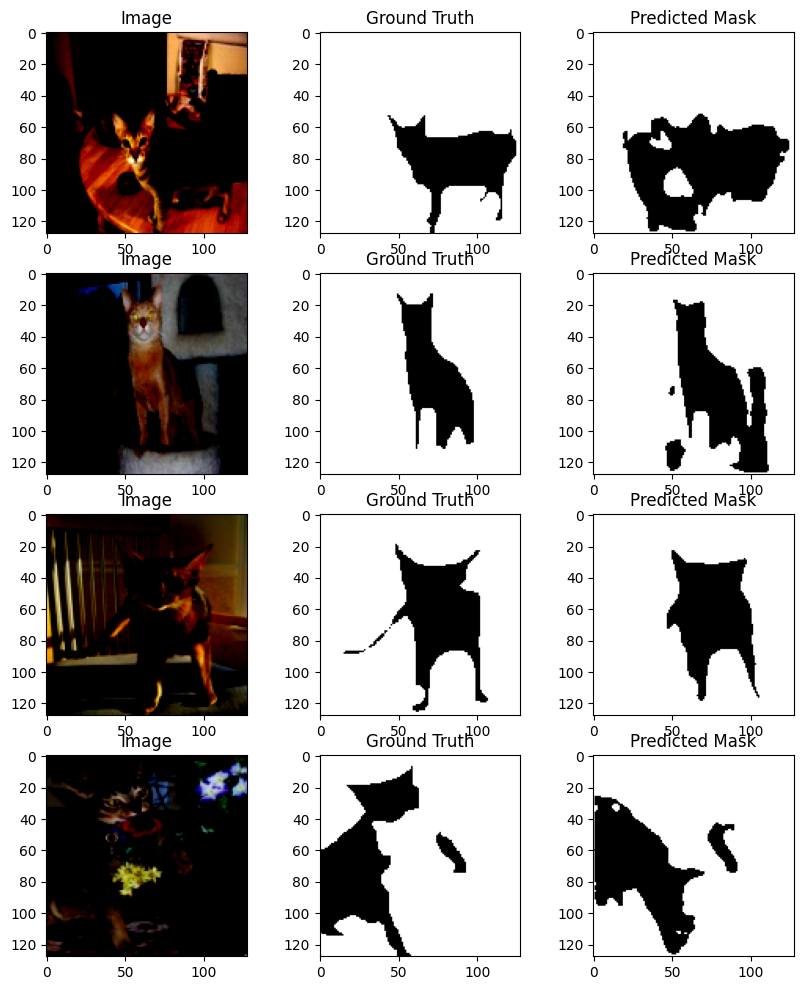

In [115]:
for en, trainer in enumerate(custom_results):
    print(en + 1)
    trainer.inference_and_plot_samples(n_samples=4)

Можно выкинуть 1 уровень и получить небольшой прирост в скорости
посмотрел логи обучения -> 

3.29it/s стало 3.52it/s
+7 % скорости